# Paso 5: EDA por Entidad (Agregaciones y Rankings)

Este notebook realiza análisis exploratorio a nivel de entidades: **AccountID**, **MerchantID** y **Channel**. 
Generamos tablas agregadas con estadísticas descriptivas, rankings y visualizaciones clave para identificar patrones de comportamiento y posibles anomalías.

## Setup: Imports y Configuración

Cargamos librerías, aplicamos estilos y verificamos el DataFrame.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Estilo seaborn
sns.set_style("whitegrid")
sns.set_palette("deep")

# Configuración de visualización
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## Cargar Dataset y Verificar

Si `df` no existe en el entorno, lo cargamos desde el archivo CSV.

In [3]:
df = pd.read_csv('../data/transacciones_banco.csv')
print("✓ Dataset cargado desde archivo CSV")

print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")

✓ Dataset cargado desde archivo CSV
Shape: (2512, 16)
Columnas: ['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


## Parsear TransactionDate a Datetime

Convertimos `TransactionDate` a datetime y creamos `TransactionDate_dt` para análisis temporal.

In [ ]:
if 'TransactionDate_dt' not in df.columns:
    df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    print("✓ TransactionDate_dt creado")
else:
    print("✓ TransactionDate_dt ya existe")

print(f"Rango de fechas: {df['TransactionDate_dt'].min()} a {df['TransactionDate_dt'].max()}")

✓ TransactionDate_dt creado
Rango de fechas: 2023-01-02 16:00:06 a 2024-01-01 18:21:50


## Crear Directorios de Salida

Creamos carpetas para guardar tablas agregadas y figuras.

In [ ]:
Path('outputs/tables').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✓ Directorios creados: outputs/tables/ y outputs/figures/")

✓ Directorios creados: outputs/tables/ y outputs/figures/


## Features Base para Agregación

Creamos features derivadas que serán útiles para las agregaciones:
- `amount_log`: logaritmo del monto (log1p para evitar problemas con ceros)
- `amount_to_balance`: ratio monto/saldo (proxy de riesgo)
- `hour`, `dayofweek`, `month`: componentes temporales

In [ ]:
# Amount log
df['amount_log'] = np.log1p(df['TransactionAmount'])

# Ratio monto/saldo (evitamos división por cero)
df['amount_to_balance'] = df['TransactionAmount'] / (df['AccountBalance'] + 1e-9)

# Features temporales
df['hour'] = df['TransactionDate_dt'].dt.hour
df['dayofweek'] = df['TransactionDate_dt'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['month'] = df['TransactionDate_dt'].dt.month

print("✓ Features base creadas:")
print(f"  - amount_log: rango [{df['amount_log'].min():.2f}, {df['amount_log'].max():.2f}]")
print(f"  - amount_to_balance: rango [{df['amount_to_balance'].min():.2e}, {df['amount_to_balance'].quantile(0.99):.2e}]")
print(f"  - hour: {df['hour'].nunique()} valores únicos")
print(f"  - dayofweek: {df['dayofweek'].nunique()} valores únicos")
print(f"  - month: {df['month'].nunique()} valores únicos")

✓ Features base creadas:
  - amount_log: rango [0.23, 7.56]
  - amount_to_balance: rango [4.47e-05, 2.29e+00]
  - hour: 3 valores únicos
  - dayofweek: 5 valores únicos
  - month: 12 valores únicos


---
# Agregación por Cuenta (AccountID)

## Construir DataFrame Agregado por Cuenta

Generamos estadísticas comprensivas para cada `AccountID`:
- Conteo de transacciones y estadísticas de montos
- Características de saldo
- Diversidad de entidades (merchants, locations, devices, IPs)
- Distribución por canales
- Login attempts y duración
- Ventana temporal de actividad

In [ ]:
print("Construyendo agregaciones por AccountID...")

# Agregaciones generales
df_account = df.groupby('AccountID').agg(
    # Conteo
    tx_count=('TransactionID', 'count'),
    
    # Estadísticas de montos
    amount_sum=('TransactionAmount', 'sum'),
    amount_mean=('TransactionAmount', 'mean'),
    amount_median=('TransactionAmount', 'median'),
    amount_max=('TransactionAmount', 'max'),
    amount_std=('TransactionAmount', 'std'),
    amount_p95=('TransactionAmount', lambda x: x.quantile(0.95)),
    amount_p99=('TransactionAmount', lambda x: x.quantile(0.99)),
    
    # Balance
    balance_mean=('AccountBalance', 'mean'),
    balance_min=('AccountBalance', 'min'),
    
    # Ratio amount/balance
    ratio_mean=('amount_to_balance', 'mean'),
    ratio_p95=('amount_to_balance', lambda x: x.quantile(0.95)),
    
    # Diversidad de entidades
    unique_merchants=('MerchantID', 'nunique'),
    unique_locations=('Location', 'nunique'),
    unique_devices=('DeviceID', 'nunique'),
    unique_ips=('IP Address', 'nunique'),
    
    # Canales
    channel_nunique=('Channel', 'nunique'),
    
    # Login attempts
    login_attempts_max=('LoginAttempts', 'max'),
    login_attempts_mean=('LoginAttempts', 'mean'),
    
    # Duración
    duration_mean=('TransactionDuration', 'mean'),
    duration_p95=('TransactionDuration', lambda x: x.quantile(0.95)),
    
    # Ventana temporal
    first_tx_date=('TransactionDate_dt', 'min'),
    last_tx_date=('TransactionDate_dt', 'max')
).reset_index()

# Calcular días activos
df_account['active_days'] = (df_account['last_tx_date'] - df_account['first_tx_date']).dt.days + 1

# Proporciones por canal
channel_shares = df.groupby(['AccountID', 'Channel']).size().unstack(fill_value=0)
channel_shares = channel_shares.div(channel_shares.sum(axis=1), axis=0)

# Agregar shares por canal (renombrar columnas)
for col in channel_shares.columns:
    df_account[f'share_{col.lower().replace(" ", "_")}'] = df_account['AccountID'].map(channel_shares[col])

df_account.fillna(0, inplace=True)

print(f"✓ df_account creado con shape: {df_account.shape}")
print(f"\nPrimeras filas:")
print(df_account.head())

Construyendo agregaciones por AccountID...
✓ df_account creado con shape: (495, 28)

Primeras filas:
  AccountID  tx_count  amount_sum  amount_mean  amount_median  amount_max  amount_std  amount_p95  amount_p99  \
0   AC00001         2      260.76   130.380000         130.38      212.97  116.799898     204.711    211.3182   
1   AC00002         7     2056.21   293.744286         331.66      516.47  195.695091     504.626    514.1012   
2   AC00003         5     1266.34   253.268000         237.97      416.62  158.484753     410.118    415.3196   
3   AC00004         9     2180.08   242.231111         136.31      642.54  231.081586     604.672    634.9664   
4   AC00005         9     3131.77   347.974444         377.92      680.76  189.487268     603.872    665.3824   

   balance_mean  balance_min  ratio_mean  ratio_p95  unique_merchants  unique_locations  unique_devices  unique_ips  \
0   2915.160000      1649.92    0.039955   0.049846                 2                 2              

## Distribución de Actividad por Cuenta

Histograma del número de transacciones por cuenta para ver la distribución de actividad.

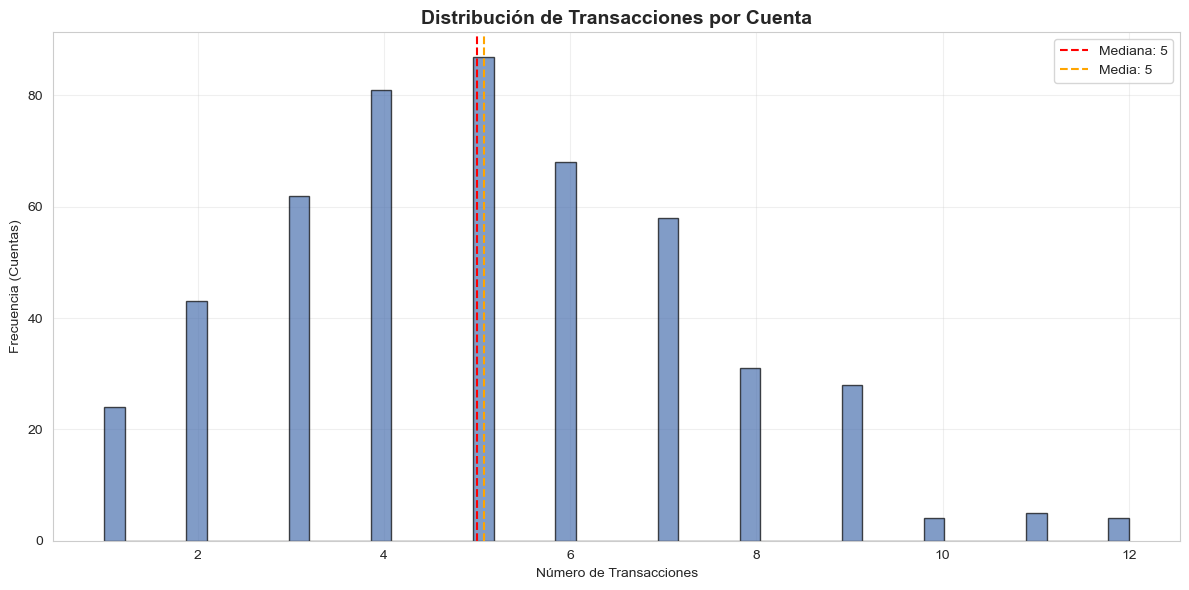

Estadísticas de tx_count por cuenta:
count    495.000000
mean       5.074747
std        2.294261
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       12.000000
Name: tx_count, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_account['tx_count'], bins=50, edgecolor='black', alpha=0.7)
ax.set_title('Distribución de Transacciones por Cuenta', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Transacciones')
ax.set_ylabel('Frecuencia (Cuentas)')
ax.grid(True, alpha=0.3)
ax.axvline(df_account['tx_count'].median(), color='red', linestyle='--', label=f"Mediana: {df_account['tx_count'].median():.0f}")
ax.axvline(df_account['tx_count'].mean(), color='orange', linestyle='--', label=f"Media: {df_account['tx_count'].mean():.0f}")
ax.legend()

plt.tight_layout()
plt.savefig('outputs/figures/account_tx_count_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Estadísticas de tx_count por cuenta:")
print(df_account['tx_count'].describe())

## Scatter: Actividad vs Monto Promedio

Scatterplot para identificar cuentas con comportamiento atípico (alta actividad + montos altos/bajos).

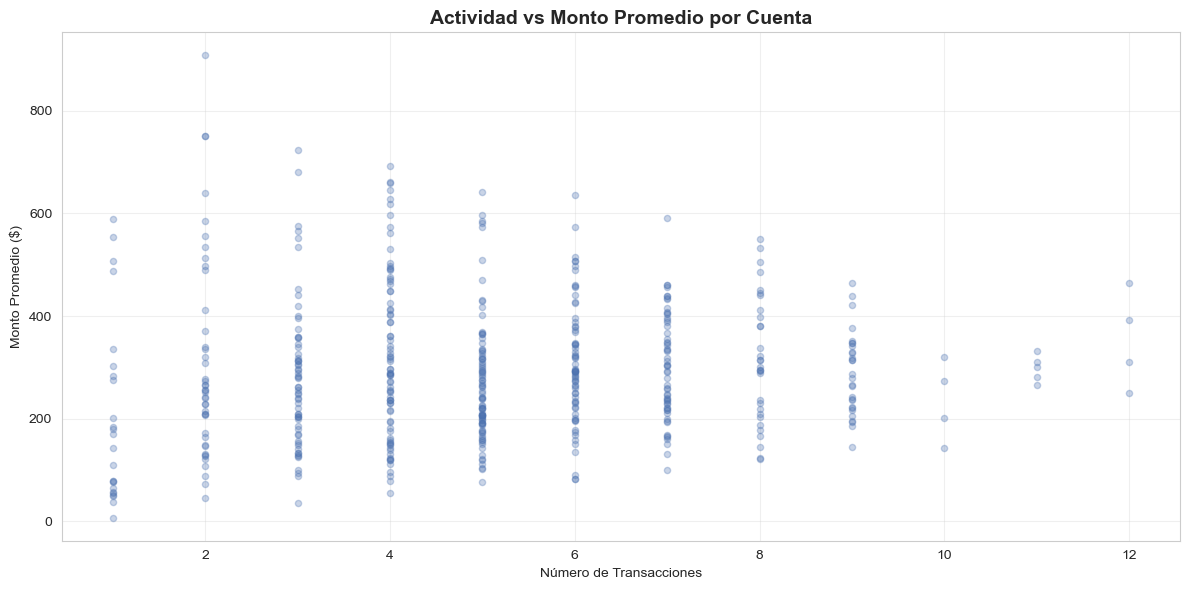

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df_account['tx_count'], df_account['amount_mean'], alpha=0.3, s=20)
ax.set_title('Actividad vs Monto Promedio por Cuenta', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Transacciones')
ax.set_ylabel('Monto Promedio ($)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/account_activity_vs_amount.png', dpi=100, bbox_inches='tight')
plt.show()

## TOP 10 Cuentas por Actividad

Las cuentas con mayor número de transacciones.

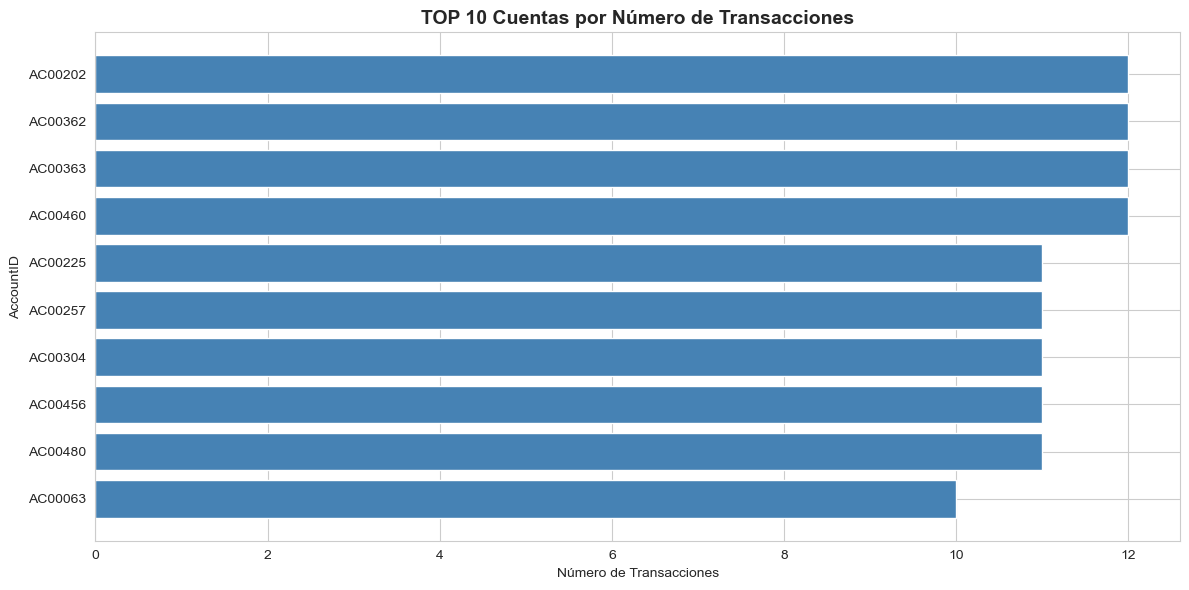

TOP 10 Cuentas por actividad:
    AccountID  tx_count  amount_mean  unique_merchants
200   AC00202        12   310.176667                12
357   AC00362        12   249.276667                11
358   AC00363        12   391.909167                12
455   AC00460        12   464.195000                10
223   AC00225        11   266.027273                11
253   AC00257        11   310.001818                11
300   AC00304        11   331.981818                11
451   AC00456        11   280.963636                11
475   AC00480        11   300.863636                10
61    AC00063        10   319.272000                10


In [ ]:
top_accounts_by_count = df_account.nlargest(10, 'tx_count')[['AccountID', 'tx_count', 'amount_mean', 'unique_merchants']]

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_accounts_by_count['AccountID'].astype(str), top_accounts_by_count['tx_count'], color='steelblue')
ax.set_title('TOP 10 Cuentas por Número de Transacciones', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Transacciones')
ax.set_ylabel('AccountID')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/figures/top10_accounts_by_count.png', dpi=100, bbox_inches='tight')
plt.show()

print("TOP 10 Cuentas por actividad:")
print(top_accounts_by_count)

## TOP 10 Cuentas por Monto Máximo

Las cuentas con transacciones de mayor monto individual.

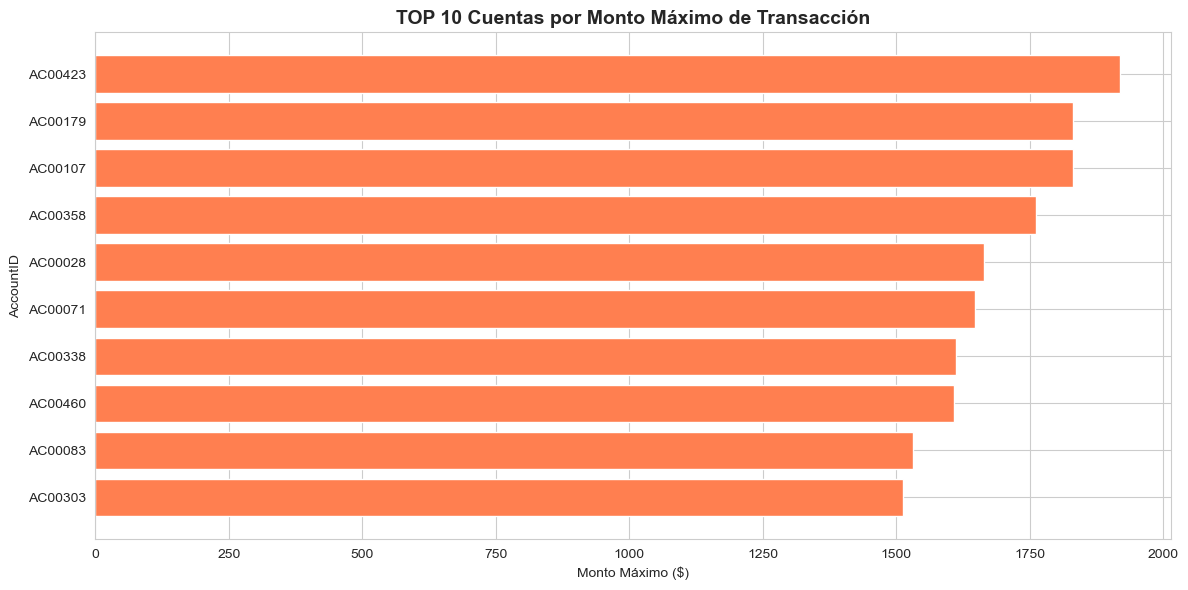

TOP 10 Cuentas por monto máximo:
    AccountID  amount_max  tx_count  balance_mean
418   AC00423     1919.11         6   5645.848333
177   AC00179     1831.02         6   8851.878333
105   AC00107     1830.00         5   3541.558000
353   AC00358     1762.28         8   5731.018750
27    AC00028     1664.33         3   1610.466667
69    AC00071     1647.74         8   1760.048750
334   AC00338     1612.37         7   3110.275714
455   AC00460     1607.55        12   4887.100833
81    AC00083     1531.31         6   3086.276667
299   AC00303     1512.99         6   5414.301667


In [ ]:
top_accounts_by_max = df_account.nlargest(10, 'amount_max')[['AccountID', 'amount_max', 'tx_count', 'balance_mean']]

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_accounts_by_max['AccountID'].astype(str), top_accounts_by_max['amount_max'], color='coral')
ax.set_title('TOP 10 Cuentas por Monto Máximo de Transacción', fontsize=14, fontweight='bold')
ax.set_xlabel('Monto Máximo ($)')
ax.set_ylabel('AccountID')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/figures/top10_accounts_by_max_amount.png', dpi=100, bbox_inches='tight')
plt.show()

print("TOP 10 Cuentas por monto máximo:")
print(top_accounts_by_max)

## Guardar Tabla Agregada de Cuentas

Exportamos `df_account` a CSV para uso posterior.

In [ ]:
df_account.to_csv('outputs/tables/df_account_features.csv', index=False)
print(f"✓ Tabla guardada: outputs/tables/df_account_features.csv")
print(f"  Shape: {df_account.shape}")
print(f"  Columnas: {list(df_account.columns)}")

✓ Tabla guardada: outputs/tables/df_account_features.csv
  Shape: (495, 28)
  Columnas: ['AccountID', 'tx_count', 'amount_sum', 'amount_mean', 'amount_median', 'amount_max', 'amount_std', 'amount_p95', 'amount_p99', 'balance_mean', 'balance_min', 'ratio_mean', 'ratio_p95', 'unique_merchants', 'unique_locations', 'unique_devices', 'unique_ips', 'channel_nunique', 'login_attempts_max', 'login_attempts_mean', 'duration_mean', 'duration_p95', 'first_tx_date', 'last_tx_date', 'active_days', 'share_atm', 'share_branch', 'share_online']


---
# Agregación por Comercio (MerchantID)

## Construir DataFrame Agregado por Comercio

Generamos estadísticas para cada `MerchantID`:
- Actividad transaccional
- Estadísticas de montos
- Diversidad de clientes y dispositivos
- Distribución por canales

In [ ]:
print("Construyendo agregaciones por MerchantID...")

df_merchant = df.groupby('MerchantID').agg(
    # Conteo
    tx_count=('TransactionID', 'count'),
    
    # Estadísticas de montos
    amount_mean=('TransactionAmount', 'mean'),
    amount_median=('TransactionAmount', 'median'),
    amount_max=('TransactionAmount', 'max'),
    amount_p95=('TransactionAmount', lambda x: x.quantile(0.95)),
    
    # Diversidad
    unique_accounts=('AccountID', 'nunique'),
    unique_devices=('DeviceID', 'nunique'),
    unique_ips=('IP Address', 'nunique'),
    
    # Canales
    channel_nunique=('Channel', 'nunique')
).reset_index()

# Proporciones por canal
merchant_channel_shares = df.groupby(['MerchantID', 'Channel']).size().unstack(fill_value=0)
merchant_channel_shares = merchant_channel_shares.div(merchant_channel_shares.sum(axis=1), axis=0)

for col in merchant_channel_shares.columns:
    df_merchant[f'share_{col.lower().replace(" ", "_")}'] = df_merchant['MerchantID'].map(merchant_channel_shares[col])

df_merchant.fillna(0, inplace=True)

print(f"✓ df_merchant creado con shape: {df_merchant.shape}")
print(f"\nPrimeras filas:")
print(df_merchant.head())

Construyendo agregaciones por MerchantID...
✓ df_merchant creado con shape: (100, 13)

Primeras filas:
  MerchantID  tx_count  amount_mean  amount_median  amount_max  amount_p95  unique_accounts  unique_devices  \
0       M001        32   260.002500        145.850     1362.55    707.5045               31              31   
1       M002        31   290.427097        219.630      858.63    780.7350               31              31   
2       M003        26   214.016923        182.405      870.30    571.1075               26              25   
3       M004        31   265.268387        124.720     1309.79   1047.6400               30              31   
4       M005        32   346.872813        275.325     1168.26   1105.6415               31              32   

   unique_ips  channel_nunique  share_atm  share_branch  share_online  
0          32                3   0.375000      0.281250      0.343750  
1          30                3   0.193548      0.483871      0.322581  
2          25 

## TOP 10 Comercios por Actividad

Los comercios con mayor número de transacciones.

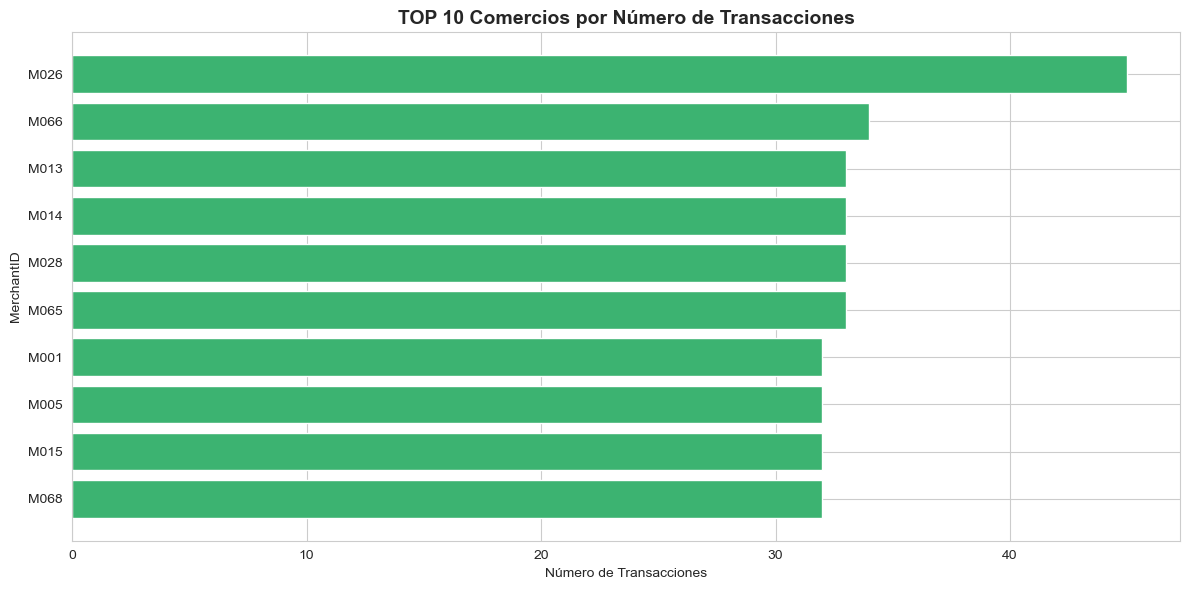

TOP 10 Comercios por actividad:
   MerchantID  tx_count  amount_median  unique_accounts
25       M026        45        185.990               44
65       M066        34        244.210               34
12       M013        33        236.810               32
13       M014        33        256.800               33
27       M028        33        180.940               32
64       M065        33        166.550               31
0        M001        32        145.850               31
4        M005        32        275.325               31
14       M015        32        171.250               31
67       M068        32        269.905               31


In [ ]:
top_merchants_by_count = df_merchant.nlargest(10, 'tx_count')[['MerchantID', 'tx_count', 'amount_median', 'unique_accounts']]

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_merchants_by_count['MerchantID'].astype(str), top_merchants_by_count['tx_count'], color='mediumseagreen')
ax.set_title('TOP 10 Comercios por Número de Transacciones', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Transacciones')
ax.set_ylabel('MerchantID')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/figures/top10_merchants_by_count.png', dpi=100, bbox_inches='tight')
plt.show()

print("TOP 10 Comercios por actividad:")
print(top_merchants_by_count)

## TOP 10 Comercios por Monto P95

Los comercios con mayor monto en el percentil 95 (colas altas).

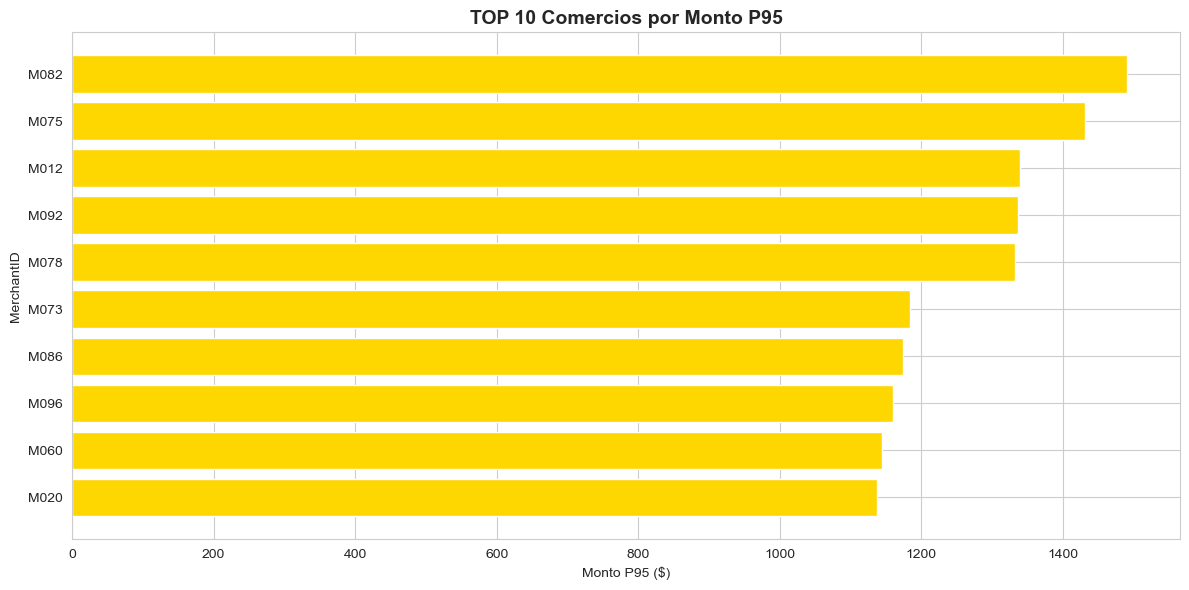

TOP 10 Comercios por monto P95:
   MerchantID  amount_p95  amount_median  tx_count
81       M082   1491.1050        212.470        18
74       M075   1431.3510        389.050        19
11       M012   1340.1900        254.370        21
91       M092   1337.0650        151.235        22
77       M078   1332.5900        199.090        25
72       M073   1183.6775        219.380        24
85       M086   1173.7400        325.980        21
95       M096   1160.5310        140.700        28
59       M060   1144.5405        173.510        30
19       M020   1137.0260        205.140        22


In [ ]:
top_merchants_by_p95 = df_merchant.nlargest(10, 'amount_p95')[['MerchantID', 'amount_p95', 'amount_median', 'tx_count']]

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_merchants_by_p95['MerchantID'].astype(str), top_merchants_by_p95['amount_p95'], color='gold')
ax.set_title('TOP 10 Comercios por Monto P95', fontsize=14, fontweight='bold')
ax.set_xlabel('Monto P95 ($)')
ax.set_ylabel('MerchantID')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/figures/top10_merchants_by_p95.png', dpi=100, bbox_inches='tight')
plt.show()

print("TOP 10 Comercios por monto P95:")
print(top_merchants_by_p95)

## Guardar Tabla Agregada de Comercios

Exportamos `df_merchant` a CSV.

In [ ]:
df_merchant.to_csv('outputs/tables/df_merchant_features.csv', index=False)
print(f"✓ Tabla guardada: outputs/tables/df_merchant_features.csv")
print(f"  Shape: {df_merchant.shape}")

✓ Tabla guardada: outputs/tables/df_merchant_features.csv
  Shape: (100, 13)


---
# Agregación por Canal (Channel)

## Construir DataFrame Agregado por Canal

Generamos estadísticas para cada `Channel`:
- Actividad transaccional
- Estadísticas de montos
- Login attempts y duración
- Diversidad de cuentas y comercios

In [ ]:
print("Construyendo agregaciones por Channel...")

df_channel = df.groupby('Channel').agg(
    # Conteo
    tx_count=('TransactionID', 'count'),
    
    # Estadísticas de montos
    amount_mean=('TransactionAmount', 'mean'),
    amount_median=('TransactionAmount', 'median'),
    amount_p95=('TransactionAmount', lambda x: x.quantile(0.95)),
    
    # Login attempts
    login_attempts_mean=('LoginAttempts', 'mean'),
    login_attempts_max=('LoginAttempts', 'max'),
    
    # Duración
    duration_mean=('TransactionDuration', 'mean'),
    duration_p95=('TransactionDuration', lambda x: x.quantile(0.95)),
    
    # Diversidad
    unique_accounts=('AccountID', 'nunique'),
    unique_merchants=('MerchantID', 'nunique')
).reset_index()

print(f"✓ df_channel creado con shape: {df_channel.shape}")
print("\nTabla completa por canal:")
print(df_channel)

Construyendo agregaciones por Channel...
✓ df_channel creado con shape: (3, 11)

Tabla completa por canal:
  Channel  tx_count  amount_mean  amount_median  amount_p95  login_attempts_mean  login_attempts_max  duration_mean  \
0     ATM       833   307.720804         218.96    898.3220             1.123649                   5     122.091236   
1  Branch       868   288.229263         204.16    852.1235             1.122120                   5     116.675115   
2  Online       811   297.214723         206.63    889.6250             1.128237                   5     120.305795   

   duration_p95  unique_accounts  unique_merchants  
0         263.0              403               100  
1         263.3              400               100  
2         272.5              399               100  


## Boxplot: TransactionAmount por Canal (Escala Log)

Comparamos la distribución de montos entre canales usando escala logarítmica.

C:\Users\joako\AppData\Local\Temp\ipykernel_7484\1209024504.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Channel', y='amount_log', ax=ax, palette='Set2')


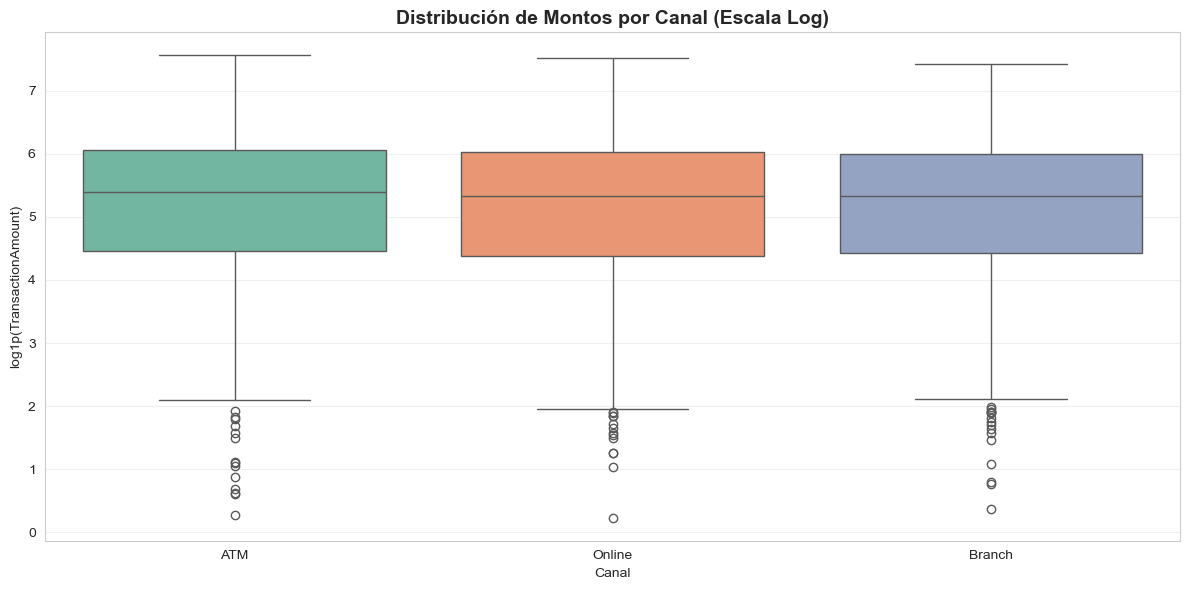

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df, x='Channel', y='amount_log', ax=ax, palette='Set2')
ax.set_title('Distribución de Montos por Canal (Escala Log)', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('log1p(TransactionAmount)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/amount_by_channel_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

## Barplot: Volumen de Transacciones por Canal

Comparamos el número de transacciones entre canales.

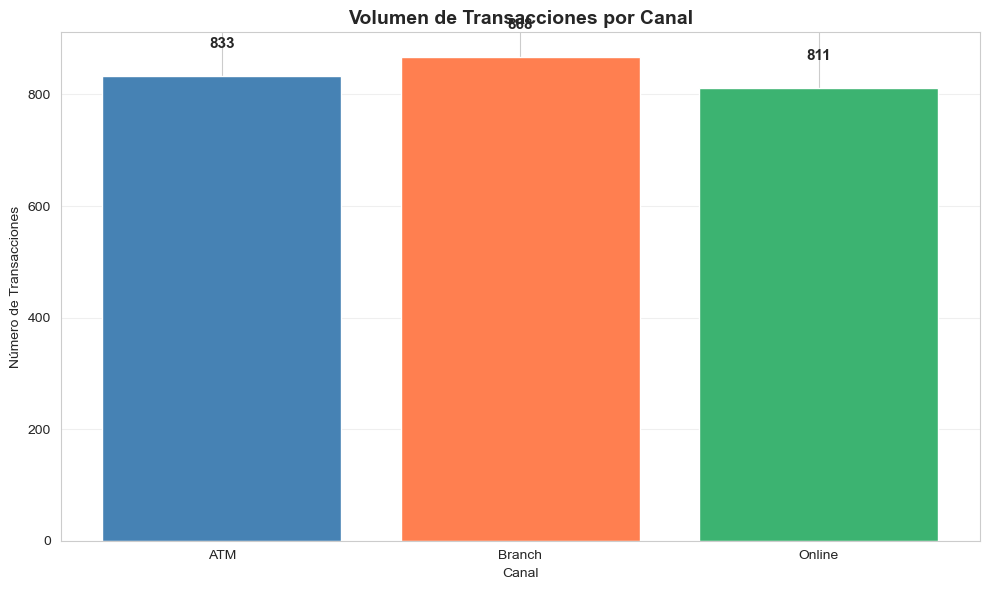

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df_channel['Channel'], df_channel['tx_count'], color=['steelblue', 'coral', 'mediumseagreen'])
ax.set_title('Volumen de Transacciones por Canal', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('Número de Transacciones')
ax.grid(True, alpha=0.3, axis='y')

# Agregar valores sobre las barras
for i, (channel, count) in enumerate(zip(df_channel['Channel'], df_channel['tx_count'])):
    ax.text(i, count + 50, f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Guardar Tabla Agregada por Canal

Exportamos `df_channel` a CSV.

In [ ]:
df_channel.to_csv('outputs/tables/df_channel_features.csv', index=False)
print(f"✓ Tabla guardada: outputs/tables/df_channel_features.csv")
print(f"  Shape: {df_channel.shape}")

✓ Tabla guardada: outputs/tables/df_channel_features.csv
  Shape: (3, 11)


---
# Rankings "Proxy" de Riesgo

Identificamos cuentas y comercios con comportamientos extremos que pueden indicar riesgo potencial.
**IMPORTANTE:** Esto NO es detección de fraude, solo rankings de comportamiento inusual.

## TOP 10 Cuentas con Mayor Número de IPs Únicas

Alta diversidad de IPs puede indicar comportamiento sospechoso.

In [21]:
top_accounts_unique_ips = df_account.nlargest(10, 'unique_ips')[['AccountID', 'unique_ips', 'tx_count', 'unique_devices']]

print("TOP 10 Cuentas con mayor número de IPs únicas:")
print(top_accounts_unique_ips)
print(f"\nInterpretación: Cuentas con muchas IPs diferentes pueden indicar:")
print("  - Uso compartido de cuenta")
print("  - Acceso desde múltiples ubicaciones geográficas")
print("  - Posible compromiso de cuenta")

TOP 10 Cuentas con mayor número de IPs únicas:
    AccountID  unique_ips  tx_count  unique_devices
200   AC00202          12        12              12
357   AC00362          12        12              12
358   AC00363          12        12              12
455   AC00460          12        12              12
253   AC00257          11        11              11
300   AC00304          11        11              11
451   AC00456          11        11              11
475   AC00480          11        11              10
61    AC00063          10        10              10
217   AC00219          10        10              10

Interpretación: Cuentas con muchas IPs diferentes pueden indicar:
  - Uso compartido de cuenta
  - Acceso desde múltiples ubicaciones geográficas
  - Posible compromiso de cuenta


## TOP 10 Cuentas con Mayor Número de Dispositivos Únicos

Alta diversidad de dispositivos puede ser señal de alerta.

In [22]:
top_accounts_unique_devices = df_account.nlargest(10, 'unique_devices')[['AccountID', 'unique_devices', 'tx_count', 'unique_ips']]

print("TOP 10 Cuentas con mayor número de dispositivos únicos:")
print(top_accounts_unique_devices)
print(f"\nInterpretación: Similar a IPs, muchos dispositivos pueden indicar comportamiento anómalo.")

TOP 10 Cuentas con mayor número de dispositivos únicos:
    AccountID  unique_devices  tx_count  unique_ips
200   AC00202              12        12          12
357   AC00362              12        12          12
358   AC00363              12        12          12
455   AC00460              12        12          12
223   AC00225              11        11          10
253   AC00257              11        11          11
300   AC00304              11        11          11
451   AC00456              11        11          11
61    AC00063              10        10          10
217   AC00219              10        10          10

Interpretación: Similar a IPs, muchos dispositivos pueden indicar comportamiento anómalo.


## TOP 10 Comercios con Mayor Número de Cuentas Únicas

Comercios que atienden muchas cuentas diferentes (alta popularidad o patrones inusuales).

In [23]:
top_merchants_unique_accounts = df_merchant.nlargest(10, 'unique_accounts')[['MerchantID', 'unique_accounts', 'tx_count', 'amount_median']]

print("TOP 10 Comercios con mayor número de cuentas únicas:")
print(top_merchants_unique_accounts)
print(f"\nInterpretación: Comercios muy populares o potenciales 'mulas' en esquemas de fraude.")

TOP 10 Comercios con mayor número de cuentas únicas:
   MerchantID  unique_accounts  tx_count  amount_median
25       M026               44        45        185.990
65       M066               34        34        244.210
13       M014               33        33        256.800
12       M013               32        33        236.810
27       M028               32        33        180.940
0        M001               31        32        145.850
1        M002               31        31        219.630
4        M005               31        32        275.325
14       M015               31        32        171.250
24       M025               31        31        217.610

Interpretación: Comercios muy populares o potenciales 'mulas' en esquemas de fraude.


## TOP 10 Cuentas con Mayor Ratio Monto/Saldo (P95)

Cuentas que transaccionan montos muy altos relativos a su saldo (riesgo de sobregiro o fraude).

In [24]:
top_accounts_ratio = df_account.nlargest(10, 'ratio_p95')[['AccountID', 'ratio_p95', 'amount_p95', 'balance_mean', 'tx_count']]

print("TOP 10 Cuentas con mayor ratio monto/saldo (P95):")
print(top_accounts_ratio)
print(f"\nInterpretación: Ratios altos pueden indicar:")
print("  - Transacciones que exceden la capacidad del saldo")
print("  - Cuentas con saldos muy bajos pero actividad alta")
print("  - Posible fraude o uso indebido")

TOP 10 Cuentas con mayor ratio monto/saldo (P95):
    AccountID  ratio_p95  amount_p95  balance_mean  tx_count
352   AC00357   5.939483    701.8225   4306.788333         6
129   AC00131   4.908876    737.3900   4672.113333         9
281   AC00285   4.094716   1055.5400   5298.985714         7
117   AC00119   3.785178    673.7000   7481.866667         6
19    AC00020   3.723100    769.9520   3833.627778         9
402   AC00407   3.378252    817.6910   4593.850000         7
449   AC00454   3.261296   1063.1590   2173.075000         4
260   AC00264   3.257029    749.8125   2540.175000         6
489   AC00495   3.163660    725.6085   2709.593750         8
134   AC00136   3.039595    834.7715   5374.211250         8

Interpretación: Ratios altos pueden indicar:
  - Transacciones que exceden la capacidad del saldo
  - Cuentas con saldos muy bajos pero actividad alta
  - Posible fraude o uso indebido
